In [29]:
import xgboost as xgb
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

# Suppress warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

In [30]:
df = pd.read_csv(r"C:\Users\lexgu\Downloads\UR3 CobotOps Data - Sheet1.csv")
columns_to_drop = ['Timestamp']
df = df.drop(columns = columns_to_drop, axis=1)


In [31]:
#dataframe with only speed + grip_lost

columns_to_drop = ['Num', 'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5', 'Temperature_T0', 'Temperature_J1', 'Temperature_J2', 'Temperature_J3', 'Temperature_J4', 'Temperature_J5', 'cycle', 'Tool_current', 'Robot_ProtectiveStop']
df_1 = df.drop(columns = columns_to_drop, axis=1)
#clean data
df_cleaned = df_1.dropna()

#make speed values only positive
columns_to_modify = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']

for column in columns_to_modify:
    df_cleaned[column] = df_cleaned[column].abs()
df_cleaned = df_cleaned.loc[~(df_cleaned == 0).all(axis=1)]
df_cleaned

C:\Users\lexgu\AppData\Local\Temp\ipykernel_12300\1244227010.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[column] = df_cleaned[column].abs()


,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,grip_lost
0,2.955651e-01,0.000490,1.310194e-03,1.328356e-01,0.007479,0.152962,False
1,7.390000e-30,0.000304,2.185137e-03,1.668227e-03,0.000767,0.000417,False
2,1.369386e-01,0.007795,2.535874e+00,3.798670e-01,0.000455,0.496856,False
3,9.030032e-02,0.004911,9.096014e-03,3.841961e-01,0.018411,0.425559,False
4,1.268088e-01,0.005567,1.138345e-03,3.532840e-01,0.014994,0.180989,False
...,...,...,...,...,...,...,...
7398,7.402850e-03,0.183715,3.703889e-01,9.463752e-03,0.000351,0.135950,False
7399,1.288373e-01,0.017049,9.448170e-03,1.612025e-01,0.047146,0.055798,False
7400,5.060138e-02,0.000000,2.200000e-16,1.376524e-02,0.001019,0.024078,False
7401,1.398979e-01,0.000353,3.307879e-03,1.283190e-01,0.005365,0.006288,False


In [32]:
X = df_cleaned.drop('grip_lost', axis = 1)

y = df_cleaned['grip_lost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

#generatic synthetic samples for minority class using SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_train

,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5
0,0.000000,1.540000e-43,0.000000e+00,0.000029,0.000000e+00,0.000038
1,0.000000,1.566940e-04,4.560000e-25,0.001051,0.000000e+00,0.000073
2,0.532631,2.321450e-04,1.810300e-02,0.287956,1.708725e-02,0.274231
3,0.282825,6.349570e-04,6.187117e-03,0.231651,9.736068e-03,0.050953
4,0.000066,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000062
...,...,...,...,...,...,...
8025,0.171319,5.751485e-03,4.384939e-03,0.447861,8.737541e-02,0.223122
8026,0.080691,3.702140e-03,2.637694e-04,0.111491,2.850819e-02,0.022453
8027,0.019754,1.136088e-03,3.158770e-05,0.039283,7.528083e-03,0.010881
8028,0.000540,2.643362e-03,2.603127e+00,0.586411,2.378737e-15,0.643392


In [33]:
xgboost = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgboost.fit(X_train, y_train)
xgboost_pred = xgboost.predict(X_test)

In [34]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=xgboost, param_grid=param_grid, cv=3, scoring='f1_macro', verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f'Best parameters found: {best_params}')

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


# Evaluate the model
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [35]:
xgboost_tuned_results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=1),
    'Recall': recall_score(y_test, y_pred, zero_division=1),
    'F1 Score': f1_score(y_test, y_pred, zero_division=1)
}
print(xgboost_tuned_results)

NameError: name 'y_pred' is not defined

f_weighted {'Accuracy': 0.9592633928571429, 'Precision': 0.59375, 'Recall': 0.24050632911392406, 'F1 Score': 0.34234234234234234}f_macro


In [37]:
#random forest
#ADJUST CV (CROSS VALIDATION)
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameters grid to search
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=2, n_jobs=-1, verbose=2, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

Fitting 2 folds for each of 960 candidates, totalling 1920 fits


KeyboardInterrupt: 

In [38]:
#Tuned XGBoost
bestParams = {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

rf_tuned = xgb.XGBClassifier(**bestParams)
rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

rf_tuned_results = {
    'Accuracy': accuracy_score(y_test, rf_tuned_pred),
    'Precision': precision_score(y_test, rf_tuned_pred, zero_division=1),
    'Recall': recall_score(y_test, rf_tuned_pred, zero_division=1),
    'F1 Score': f1_score(y_test, rf_tuned_pred, zero_division=1)
}
print(rf_tuned_results)

{'Accuracy': 0.9268973214285714, 'Precision': 0.2833333333333333, 'Recall': 0.43037974683544306, 'F1 Score': 0.3417085427135678}


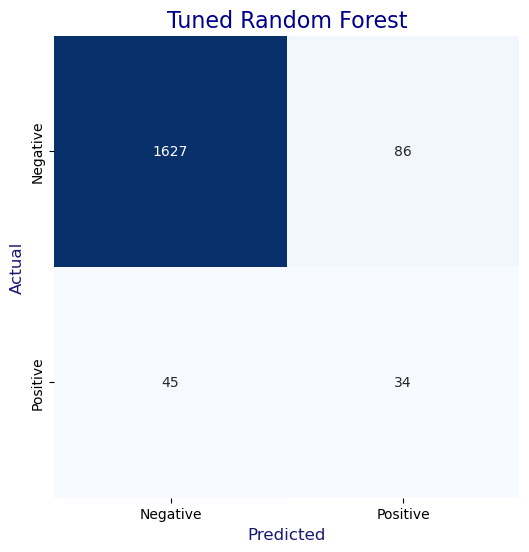

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix
cm = confusion_matrix(y_test, rf_tuned_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])

# Customizing title, labels, and other plot elements
plt.title('Tuned Random Forest', fontsize=16, color='darkblue')
plt.xlabel('Predicted', fontsize=12, color='midnightblue')
plt.ylabel('Actual', fontsize=12, color='midnightblue')

plt.show()

In [ ]:
# Use the best parameters to make predictions on the test set
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)

rf_results = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred, zero_division=1),
    'Recall': recall_score(y_test, rf_pred, zero_division=1),
    'F1 Score': f1_score(y_test, rf_pred, zero_division=1)
}
print(rf_results)

In [ ]:
rf_pred_prob = rf_tuned.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_pred_prob)
roc_auc = roc_auc_score(y_test, rf_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tuned Random Forest Receiver Operating Curve')
plt.legend(loc="lower right")
plt.savefig('C:/plots/ROC_curves/tunedrfroc.png')
plt.show()

In [40]:
importances = rf_tuned.feature_importances_
feature_names = X_train.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances

,Feature,Importance
0,Speed_J0,0.160583
1,Speed_J1,0.214413
2,Speed_J2,0.130282
3,Speed_J3,0.181770
4,Speed_J4,0.203531
5,Speed_J5,0.109421


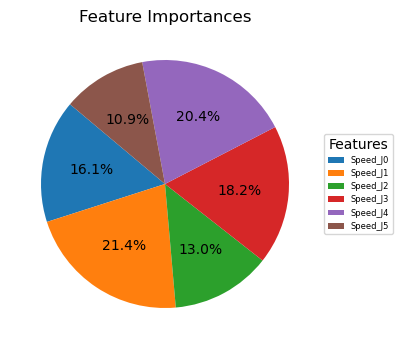

In [52]:
plt.figure(figsize=(4,4))
plt.title('Feature Importances')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
wedges, texts, autotexts = plt.pie(feature_importances['Importance'], autopct='%1.1f%%', startangle=140)
plt.legend(wedges, feature_importances['Feature'], title="Features", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), prop={'size': 6})
plt.show()